In [15]:
import pandas as pd
import numpy as np
import trial_analysis_toolbox as tb


In [67]:
# ******* EDIT THE LABEL BELOW *******
labels = ['']

# import trials csv
df_trials = pd.read_csv('../processed_data/' + labels[0] + '_trials.csv')
df_trials

,workerId,subId,interview_date,trial,block,randomized,bird_position,bag_position,bucket_position,completed,stayed,time_elapsed,label
0,5d13e3e6e51708001a43fa66,md6bevcmy7msk0cm2adjm1d3,03/08/2024,1,1,3,60.000,48.147,50,1,1,1910160,pilot1
1,5d13e3e6e51708001a43fa66,md6bevcmy7msk0cm2adjm1d3,03/08/2024,2,1,3,55.457,50.992,50,1,0,1915105,pilot1
2,5d13e3e6e51708001a43fa66,md6bevcmy7msk0cm2adjm1d3,03/08/2024,3,1,3,63.725,63.497,52,1,0,1920456,pilot1
3,5d13e3e6e51708001a43fa66,md6bevcmy7msk0cm2adjm1d3,03/08/2024,4,1,3,58.416,46.606,60,1,0,1925690,pilot1
4,5d13e3e6e51708001a43fa66,md6bevcmy7msk0cm2adjm1d3,03/08/2024,5,1,3,50.649,52.720,52,1,0,1930666,pilot1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537795,6552fd21349decf82224c708,q2bs9p66jskargfbeuga4tip,04/23/2024,46,4,2,61.360,63.048,50,1,0,1299084,run6
537796,6552fd21349decf82224c708,q2bs9p66jskargfbeuga4tip,04/23/2024,47,4,2,60.668,56.006,58,1,0,1304473,run6
537797,6552fd21349decf82224c708,q2bs9p66jskargfbeuga4tip,04/23/2024,48,4,2,58.326,58.471,54,1,0,1309567,run6
537798,6552fd21349decf82224c708,q2bs9p66jskargfbeuga4tip,04/23/2024,49,4,2,56.954,68.913,56,1,0,1315250,run6


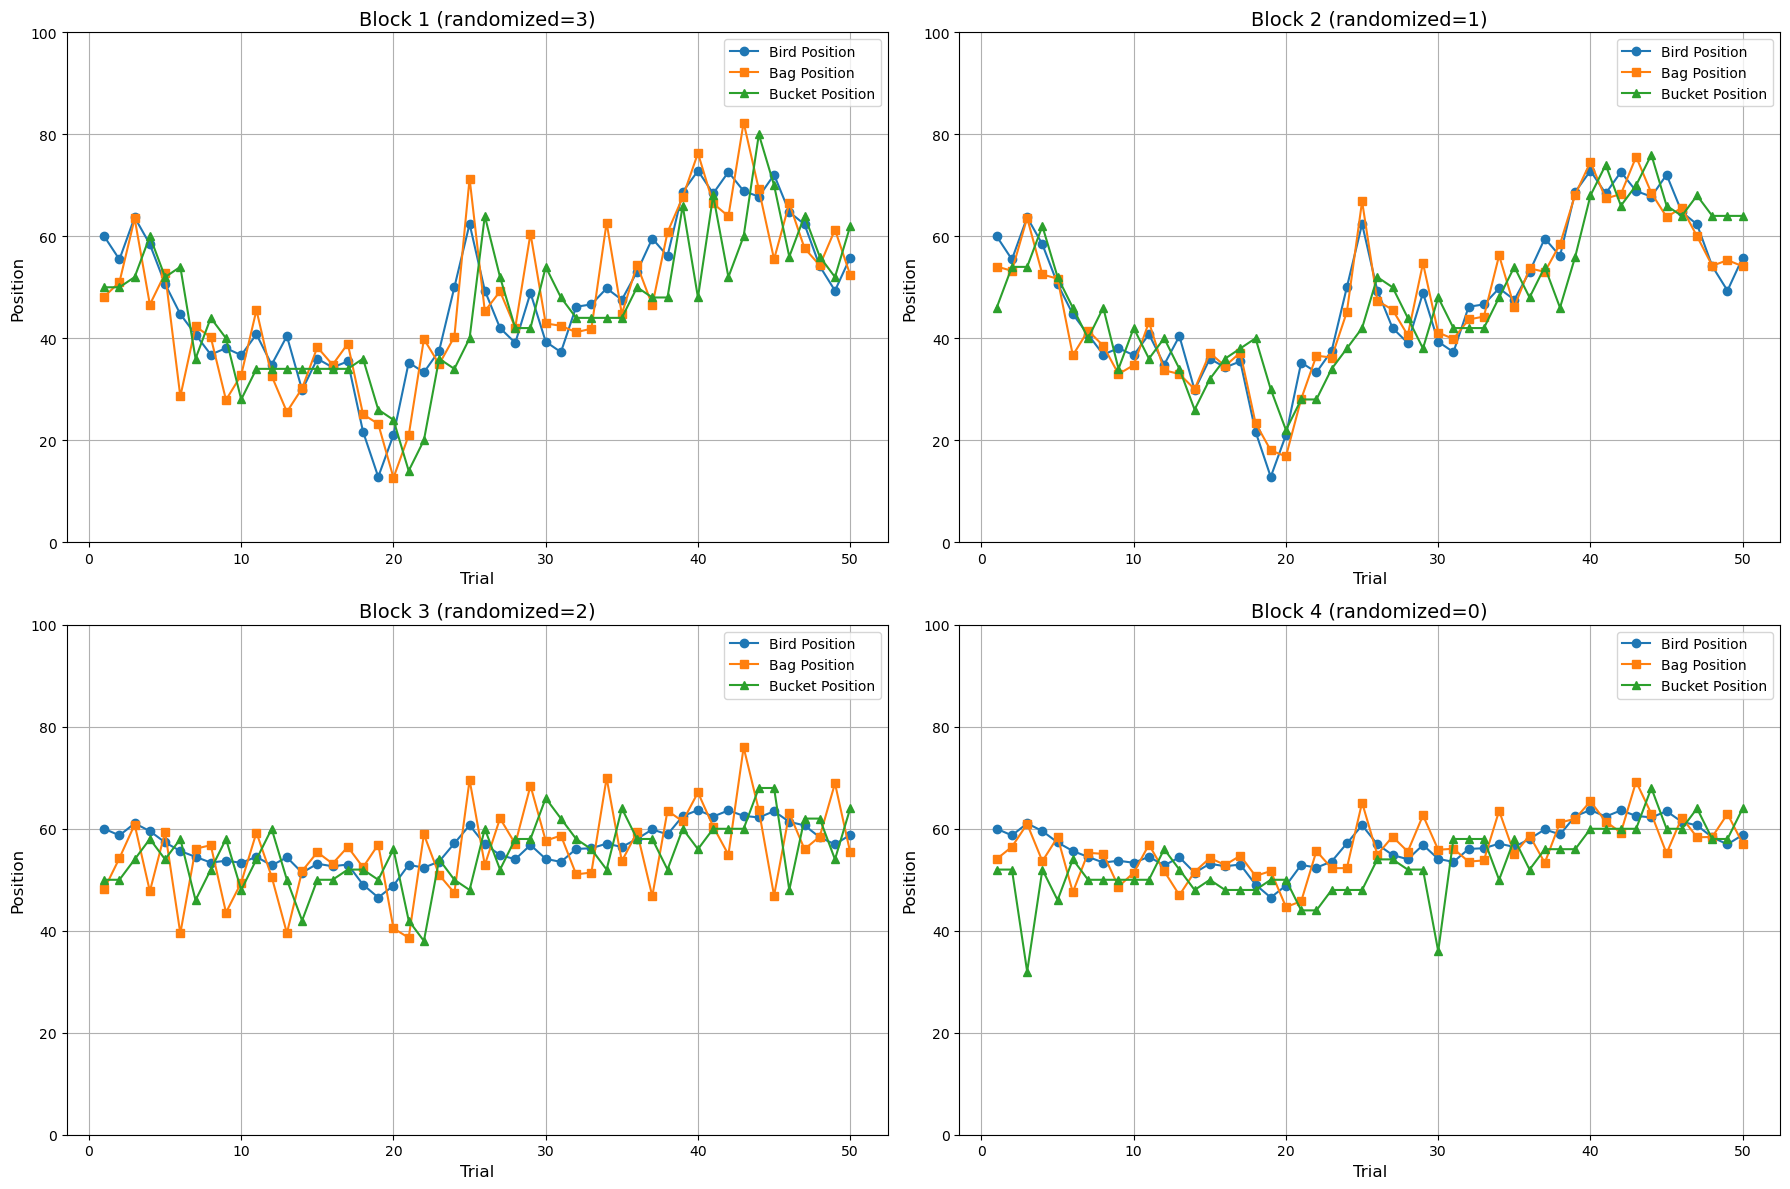

In [68]:
tb.trials_plot(df_trials)

- randomized = 0: low volatility (bird position), low stochasticity (bag position)
- randomized = 1: high volatility, low stochasticity
- randomized = 2: low volatility, high stochasticity
- randomized = 3: high volatility, high stochasticity

In [70]:
per_sub_lr = tb.model_neutral_lr(df_trials)

# extract lr from per_sub_lr
lr = []
for i in per_sub_lr:
    lr.append(i['learning_rate'])

# Preprocess data for learning rate
mean_lr = np.mean(lr, axis=0)
serr_lr = tb.serr(lr)

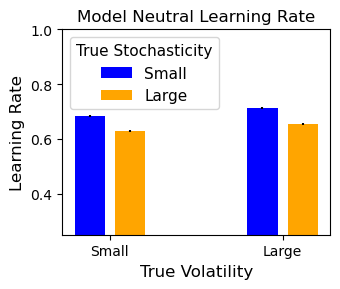

In [73]:
tb.plot_bar(mean_lr, serr_lr, ylabel='Learning Rate', xlabel='True Volatility', legend_title='True Stochasticity', title='Model Neutral Learning Rate', ylim=[0.25, 1], show_legend=True)
